<div style="border: 5px solid black; padding: 10px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Assigmnent 9.2
### **Date:** 05/11/2026

---

**Dataset was provided, no reference needed**

</div>

## **Initial Setup**

In [13]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)
np.set_printoptions(suppress=True)

# Visualization format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv('Loan_Train.csv')

# Preview
print('✅ Dataset loaded successfully!')
print(f'📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

print('🔍 First look at the data...')
display(df.head(3))

print('\n📊 Column dtypes and null counts:')
print(
    df.dtypes.to_frame(
        name='dtype').join(
            df.isnull().sum().to_frame(
                name='nulls')))

✅ Dataset loaded successfully!
📐 Shape: 614 rows × 13 columns
🔍 First look at the data...


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0000,NaN,360.0000,1.0000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,"1,508.0000",128.0000,360.0000,1.0000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0000,66.0000,360.0000,1.0000,Urban,Y



📊 Column dtypes and null counts:
                     dtype  nulls
Loan_ID                str      0
Gender                 str     13
Married                str      3
Dependents             str     15
Education              str      0
Self_Employed          str     32
ApplicantIncome      int64      0
CoapplicantIncome  float64      0
LoanAmount         float64     22
Loan_Amount_Term   float64     14
Credit_History     float64     50
Property_Area          str      0
Loan_Status            str      0


## Step 1 — Prepare the Data for Modeling

In [14]:
# Drop Loan_ID — not a predictive feature
df = df.drop(columns=['Loan_ID'])
print(
    f'🗑️ Dropped Loan_ID. Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Drop rows with any missing values
df = df.dropna()
print(
    f'🧼 Dropped rows with missing data. Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Encode target: Y -> 1, N -> 0
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
print(f'\n🏷️ Target encoded — Loan_Status value counts:')
print(df['Loan_Status'].value_counts())

# Convert remaining categoricals to dummy variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\n🔢 Encoding categorical columns: {cat_cols}')
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f'✅ After encoding. Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

🗑️ Dropped Loan_ID. Shape: 614 rows × 12 columns
🧼 Dropped rows with missing data. Shape: 480 rows × 12 columns

🏷️ Target encoded — Loan_Status value counts:
Loan_Status
1    332
0    148
Name: count, dtype: int64

🔢 Encoding categorical columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
✅ After encoding. Shape: 480 rows × 15 columns


## Step 2 — Train/Test Split

In [15]:
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✂️ Train/test split complete!')
print(f'   🏋️ Training set : {X_train.shape[0]:,} rows')
print(f'   🧪 Test set     : {X_test.shape[0]:,} rows')
print(f'   📌 Features     : {X_train.shape[1]}')

✂️ Train/test split complete!
   🏋️ Training set : 384 rows
   🧪 Test set     : 96 rows
   📌 Features     : 14


## Step 3 — Build the Pipeline (Min-Max Scaler + KNN)

In [16]:
# KNN/Min-Max Scaler
knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', KNeighborsClassifier())
])

print('🔩 Pipeline assembled!')
print(knn_pipeline)

🔩 Pipeline assembled!
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier', KNeighborsClassifier())])


## Step 4 — Fit Default KNN & Report Test Accuracy

In [17]:
# Fitting
knn_pipeline.fit(X_train, y_train)
default_accuracy = knn_pipeline.score(X_test, y_test)

print(
    f'🎯 Default KNN (k=5) Test Accuracy: {default_accuracy:.4f} ({default_accuracy * 100:.2f}%)')

🎯 Default KNN (k=5) Test Accuracy: 0.7083 (70.83%)


## Step 5 — Grid Search: Tune n_neighbors (1–10)

In [18]:
# Tuning
knn_search_space = {
    'classifier__n_neighbors': list(range(1, 11))
}

knn_grid = GridSearchCV(
    knn_pipeline,
    param_grid=knn_search_space,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

best_k = knn_grid.best_params_['classifier__n_neighbors']
knn_grid_accuracy = knn_grid.score(X_test, y_test)

print(f'🏆 Best n_neighbors       : {best_k}')
print(f'📈 Best CV accuracy       : {knn_grid.best_score_:.4f}')
print(
    f'🎯 KNN Grid Search Test Accuracy: {knn_grid_accuracy:.4f} ({knn_grid_accuracy * 100:.2f}%)')

🏆 Best n_neighbors       : 4
📈 Best CV accuracy       : 0.7498
🎯 KNN Grid Search Test Accuracy: 0.6667 (66.67%)


## Step 6 — Expanded Grid Search: KNN + Logistic Regression + Random Forest

In [19]:
# Best Model Selection
search_space = [
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': list(range(1, 11))
    },
    {
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'classifier__solver': ['liblinear']
    },
    {
        'classifier': [RandomForestClassifier()],
        'classifier__n_estimators': [10, 100, 1000],
        'classifier__max_features': [1, 2, 3]
    }
]

multi_grid = GridSearchCV(
    knn_pipeline,
    param_grid=search_space,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

multi_grid.fit(X_train, y_train)

best_model = multi_grid.best_params_
best_cv_score = multi_grid.best_score_
multi_grid_accuracy = multi_grid.score(X_test, y_test)

print(f'🏆 Best model & hyperparameters : {best_model}')
print(f'📈 Best CV accuracy             : {best_cv_score:.4f}')
print(
    f'🎯 Expanded Grid Search Test Accuracy: {multi_grid_accuracy:.4f} ({multi_grid_accuracy * 100:.2f}%)')

🏆 Best model & hyperparameters : {'classifier': LogisticRegression(max_iter=1000), 'classifier__C': 1.0, 'classifier__solver': 'liblinear'}
📈 Best CV accuracy             : 0.8020
🎯 Expanded Grid Search Test Accuracy: 0.8333 (83.33%)


## Summary

📋 Model Comparison Summary


,Model,Test Accuracy
0,Default KNN (k=5),70.83%
1,Tuned KNN (k=4),66.67%
2,Best Expanded Grid Search (Logistic Regression),83.33%



🔑 Key Takeaways:
   📌 Default KNN (k=5) established a baseline of 70.83%
   📌 Tuned KNN (k=4) slightly underperformed at 66.67%
   📌 Logistic Regression (C=1.0) was the clear winner at 83.33%
   📌 KNN struggled with this dataset likely due to the
      mix of binary dummy variables and continuous features
   📌 Logistic Regression is well-suited for binary
      classification with tabular, mixed-type feature sets


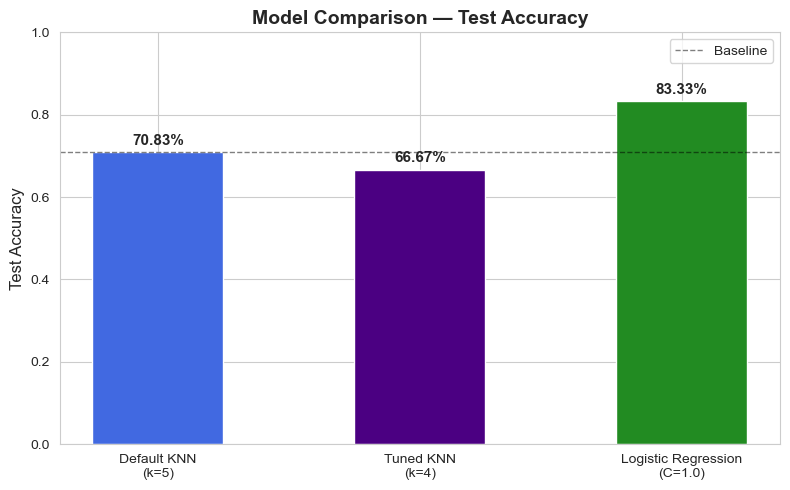

In [23]:
results = {
    'Model': [
        'Default KNN (k=5)',
        'Tuned KNN (k=4)',
        'Best Expanded Grid Search (Logistic Regression)'],
    'Test Accuracy': [
        default_accuracy,
        knn_grid_accuracy,
        multi_grid_accuracy]}

results_df = pd.DataFrame(results)
results_df['Test Accuracy'] = results_df['Test Accuracy'].map('{:.2%}'.format)

print('📋 Model Comparison Summary')
print('=' * 55)
display(results_df)

print('\n🔑 Key Takeaways:')
print('   📌 Default KNN (k=5) established a baseline of 70.83%')
print('   📌 Tuned KNN (k=4) slightly underperformed at 66.67%')
print('   📌 Logistic Regression (C=1.0) was the clear winner at 83.33%')
print('   📌 KNN struggled with this dataset likely due to the')
print('      mix of binary dummy variables and continuous features')
print('   📌 Logistic Regression is well-suited for binary')
print('      classification with tabular, mixed-type feature sets')

# Visual
fig, ax = plt.subplots(figsize=(8, 5))

models = [
    'Default KNN\n(k=5)',
    'Tuned KNN\n(k=4)',
    'Logistic Regression\n(C=1.0)']
accuracies = [default_accuracy, knn_grid_accuracy, multi_grid_accuracy]
colors = ['#4169E1', '#4B0082', '#228B22']

bars = ax.bar(models, accuracies, color=colors, width=0.5, edgecolor='white')

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.2%}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, 1.0)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(
    'Model Comparison — Test Accuracy',
    fontsize=14,
    fontweight='bold')
ax.axhline(
    y=default_accuracy,
    color='black',
    linestyle='--',
    linewidth=1,
    alpha=0.5,
    label='Baseline')
ax.legend()

plt.tight_layout()
plt.show()

<div style="border: 5px solid green; padding: 10px;">


# Reflection

## Overall Summary
This exercise focused on building and evaluating predictive models using the *Loan_Train.csv* dataset. The workflow included data cleaning, feature engineering, model construction using a pipeline, and hyperparameter tuning through grid search. After preparing the data—dropping the `Loan_ID` column, removing rows with missing values, and converting categorical variables into dummy variables—I split the dataset into training and test sets with `Loan_Status` as the target.

I first implemented a MinMaxScaler + KNN pipeline and evaluated the default model. I then tuned the `n_neighbors` parameter (1–10) using 5‑fold cross‑validation. Finally, I expanded the search space to include Logistic Regression and Random Forest models with hyperparameters from the *Machine Learning with Python Cookbook*. The best-performing model was Logistic Regression with `C = 1.0` and `solver = 'liblinear'`, achieving a test accuracy of **83.33%**, which outperformed both the default and tuned KNN models.

---

## Straightforward Aspects
Several parts of the assignment were clear and intuitive:

- **Data preparation steps** such as dropping `Loan_ID`, removing missing rows, and dummy‑encoding categorical variables followed standard preprocessing patterns I’ve used in previous coursework.
- **Pipeline construction** with MinMaxScaler and KNN was simple to implement, and fitting the pipeline worked exactly like fitting a standalone model.
- **Grid search setup** for tuning `n_neighbors` was also straightforward, especially since the search space was small and the example in the textbook aligned closely with the assignment requirements.
- **Interpreting the final grid search results** was direct: Logistic Regression emerged as the best model, and its performance improvement over KNN was easy to verify using test accuracy.

---

## More Challenging Aspects
A few components required deeper thought and presented more complexity:

- **Understanding why the tuned KNN model did not outperform the default KNN on the test set** was a key conceptual challenge. Although cross‑validation identified `n_neighbors = 4` as the best parameter, the model’s test accuracy decreased. This highlighted KNN’s sensitivity to small datasets and its tendency toward higher variance, where CV performance does not always translate to better generalization.
- **Managing the expanded grid search across three different model families** required careful attention to parameter naming conventions within the pipeline (e.g., `classifier__C`, `classifier__n_estimators`). Ensuring that each model’s hyperparameters were correctly specified and compatible with the pipeline structure took more time than expected.
- **Comparing models beyond accuracy** was another area that could be expanded. While accuracy was sufficient for the assignment, incorporating metrics like confusion matrices or classification reports would provide a more complete picture of model performance—especially for imbalanced or binary classification tasks.
- **Interpreting cross‑validation vs. test performance** across multiple models required a more nuanced understanding of bias‑variance tradeoffs and how different algorithms behave with mixed numerical and dummy‑encoded categorical features.

---

## Conclusion
Overall, this exercise strengthened my understanding of pipelines, hyperparameter tuning, and model comparison in a practical machine learning workflow. The assignment reinforced the importance of evaluating models not only through cross‑validation but also through independent test performance. It also highlighted how different algorithms respond to the same dataset and why Logistic Regression can outperform more flexible models like KNN or Random Forest when the feature space is relatively small and well‑structured.

</div>